#Importing required Libraries

In [3]:
import pandas as pd
import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, recall_score, f1_score, precision_score

Pandas and Numpy for data handling and manipulation
sklearn libraries for logistic regression, decision tree classifier, random forest classifier, and XGB classifier from XGBoost library. Then sklearn.metrics for evaluation

#Importing datasets

In [4]:
print("Loading processed datasets...")
train_df = pd.read_csv('train_processed.csv')
test_df = pd.read_csv('test_processed.csv')

#view datasets
train_df.head()

Loading processed datasets...


,Gender,Age,State,City,Account_Type,Transaction_Amount,Transaction_Type,Merchant_Category,Account_Balance,Transaction_Device,Device_Type,Transaction_Description,Transaction_Day,Transaction_Month,Transaction_DayOfWeek,Transaction_Hour,Transaction_Minute,Transaction_Second,Is_Fraud
0,0,1.174581,4,13,2,1.571774,1,2,-1.475432,14,2,57,0.978729,0.0,0.529041,1.375837,0.723361,1.125243,0
1,1,0.521167,10,14,0,-1.657985,3,0,0.721969,12,1,55,-0.289898,0.0,-1.534955,-1.518222,0.260520,-1.643133,0
2,1,-0.393613,11,37,1,1.645958,1,5,-1.542084,8,1,21,-0.059238,0.0,-0.502957,0.073511,-0.549453,-1.297086,0
3,1,-1.504417,5,21,0,0.747644,1,1,-0.990120,9,0,125,-0.405228,0.0,1.561039,-0.650004,-1.648702,-0.143596,0
4,1,-1.504417,32,27,0,1.657902,1,0,1.262492,6,3,102,-1.558525,0.0,0.013042,0.362917,1.649044,0.779196,0


In [5]:
train_df.shape

(182316, 19)

In [22]:
test_df.head()

,Gender,Age,State,City,Account_Type,Transaction_Amount,Transaction_Type,Merchant_Category,Account_Balance,Transaction_Device,Device_Type,Transaction_Description,Transaction_Day,Transaction_Month,Transaction_DayOfWeek,Transaction_Hour,Transaction_Minute,Transaction_Second,Is_Fraud
0,0,0.325143,6,55,2,1.591161,2,0,-1.600549,5,0,17,-0.981876,0.0,-1.018956,-1.518222,1.706900,1.586639,0
1,0,-1.504417,13,28,0,0.357703,2,0,0.486888,17,3,116,0.056091,0.0,0.013042,-0.071192,-0.780874,-1.470110,0
2,0,-1.177710,11,37,0,1.155124,4,1,-1.553870,1,1,93,0.863399,0.0,0.013042,1.231135,-1.301571,1.528965,0
3,1,-1.243052,19,23,2,1.482103,2,4,0.207296,12,3,118,-0.405228,0.0,1.561039,-1.373519,0.144809,-1.527784,0
4,0,-0.066906,30,6,2,-0.472974,1,2,-0.679805,9,3,163,-0.520557,0.0,1.045040,1.520540,-1.185860,0.260126,0


In [7]:
print(test_df.shape)

(40000, 19)


train_df and test_df have been scaled and normalised,
train_df shape is 182,316 x 19

test_df shape is 40,000 x 19

specify X_train and Y_train by dropping 'Is_Fraud' for X_train and assigning to Y_train

In [8]:
X_train = train_df.drop(columns=['Is_Fraud'])
y_train = train_df['Is_Fraud']
X_test = test_df.drop(columns=['Is_Fraud'])
y_test = test_df['Is_Fraud']

print(f"Training set: {X_train.shape} | Fraud rate: {y_train.mean():.4f}")
print(f"Testing set: {X_test.shape} | Fraud rate: {y_test.mean():.4f}")

Training set: (182316, 18) | Fraud rate: 0.1667
Testing set: (40000, 18) | Fraud rate: 0.0505


#Define and configure models

In [9]:
# Calculate scale_pos_weight for XGBoost based on remaining ~5:1 ratio
ratio_neg_to_pos = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced',
        max_depth=10,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        scale_pos_weight=ratio_neg_to_pos,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    )
}

A. Logistic Regression will be used as the baseline model.

*   class_weight='balanced'
*   max_iter=1000

class_weight='balanced' acts as a cost-sensitive learning rate, penalizing misclassified fraud events more heavily than legitimate ones to offset residual class discrepancies.  

B. Decision Tree (Non-Linear Rule Base), this model is good for capturing non-linear relationships.

*   max_depth=10
*   class_weight='balanced'

Without boundaries/depth, decision trees will overfit the oversampled minority cases. Limiting depth to 10 forces the model to generalize patterns rather than memorizing individual transactions, while the weight parameter balances the decision boundary.  

C. Random Forest (Bagged Ensemble) Trains an ensemble of independent decision trees over random subsets of the data and features, averaging their outputs.

*   (n_estimators=100)
*   class_weight='balanced_subsample'
*   n_jobs=-1



balanced_subsample is useful for imbalanced data. Instead of calculating weights globally, it adjusts class weights dynamically inside each bootstrap sample used to build individual trees. This ensures minority fraud instances remain influential across every tree.
n_jobs=-1 allow for parallell computing on all available cores

D. XGBoost (Gradient Boosting Machine) Trains decision trees sequentially. Each new tree focuses on correcting the gradient errors made by the previous trees.

It is Configured with 100 boosting rounds and a computed parameter scale_pos_weight set to the negative-to-positive ratio (~5.0).

Because Gradient boosting usually delivers the highest classification accuracy for tabular data. By setting scale_pos_weight, the algorithm's loss function is set to penalize false negatives (missed fraud) five times more than false positives.

#Training and Results


In [25]:
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    # Predict on test set
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

    # Save the model as a .pkl file
    model_filename = f"{name.lower().replace(' ', '_')}_model.pkl"
    joblib.dump(model, model_filename)
    print(f"Successfully saved {name} to {model_filename}")


Training Logistic Regression...
Successfully saved Logistic Regression to logistic_regression_model.pkl

Training Decision Tree...
Successfully saved Decision Tree to decision_tree_model.pkl

Training Random Forest...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Successfully saved Random Forest to random_forest_model.pkl

Training XGBoost...
Successfully saved XGBoost to xgboost_model.pkl


Print out model summary

In [18]:
print("\n" + "="*60)
print("             MODEL TRAINING SUMMARY")
print("="*60)
results_df = pd.DataFrame(results).T
print(results_df.round(4))
print("="*60)


             MODEL TRAINING SUMMARY
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.5125     0.0524  0.5069    0.0950
Decision Tree          0.5070     0.0522  0.5114    0.0948
Random Forest          0.9496     0.0000  0.0000    0.0000
XGBoost                0.7605     0.0523  0.2190    0.0845


Save model metrics to csv file

In [21]:
results_df.to_csv('model_evaluation_summary.csv', index=False)
results_df.head()

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.512525,0.052389,0.506938,0.094964
Decision Tree,0.507050,0.052216,0.511397,0.094757
Random Forest,0.949550,0.000000,0.000000,0.000000
XGBoost,0.760475,0.052326,0.219029,0.084472


### Confusion Matrices for Each Model

A confusion matrix shows the breakdown of correct and incorrect classifications for each class. It helps visualize the performance of an algorithm by showing where the model confused between different classes.


Generating Confusion Matrix for Logistic Regression...
Confusion matrix saved to logistic_regression_confusion_matrix.jpg


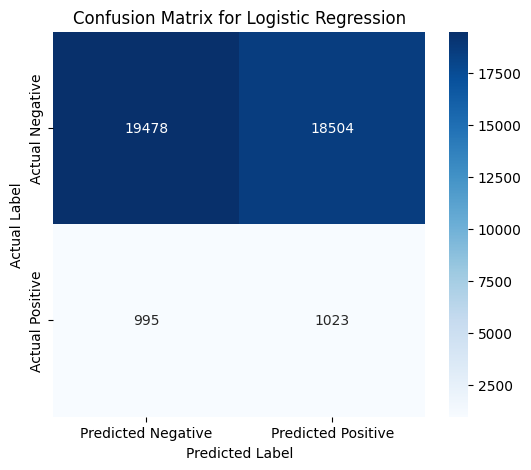


Generating Confusion Matrix for Decision Tree...
Confusion matrix saved to decision_tree_confusion_matrix.jpg


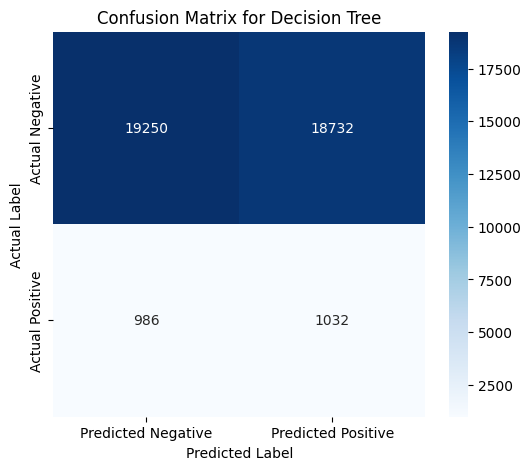


Generating Confusion Matrix for Random Forest...
Confusion matrix saved to random_forest_confusion_matrix.jpg


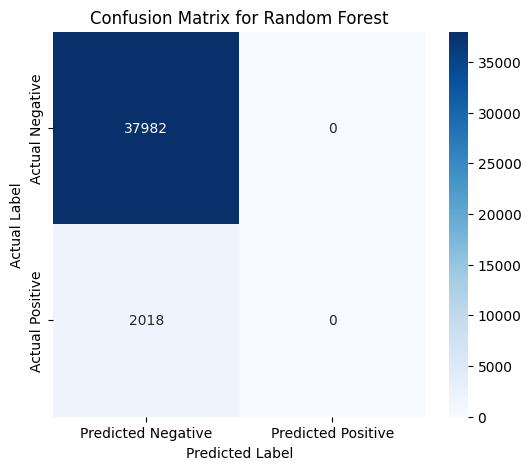


Generating Confusion Matrix for XGBoost...
Confusion matrix saved to xgboost_confusion_matrix.jpg


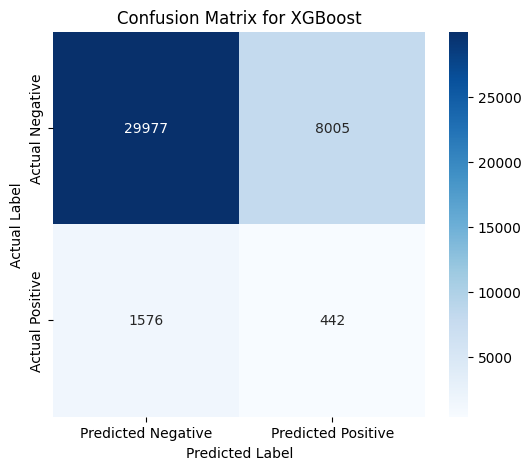

In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

for name, model in models.items():
    print(f"\nGenerating Confusion Matrix for {name}...")
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'])
    plt.title(f'Confusion Matrix for {name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')

    # Save the confusion matrix as a JPG image
    image_filename = f'{name.lower().replace(" ", "_")}_confusion_matrix.jpg'
    plt.savefig(image_filename, bbox_inches='tight', dpi=300)
    print(f"Confusion matrix saved to {image_filename}")
    plt.show()